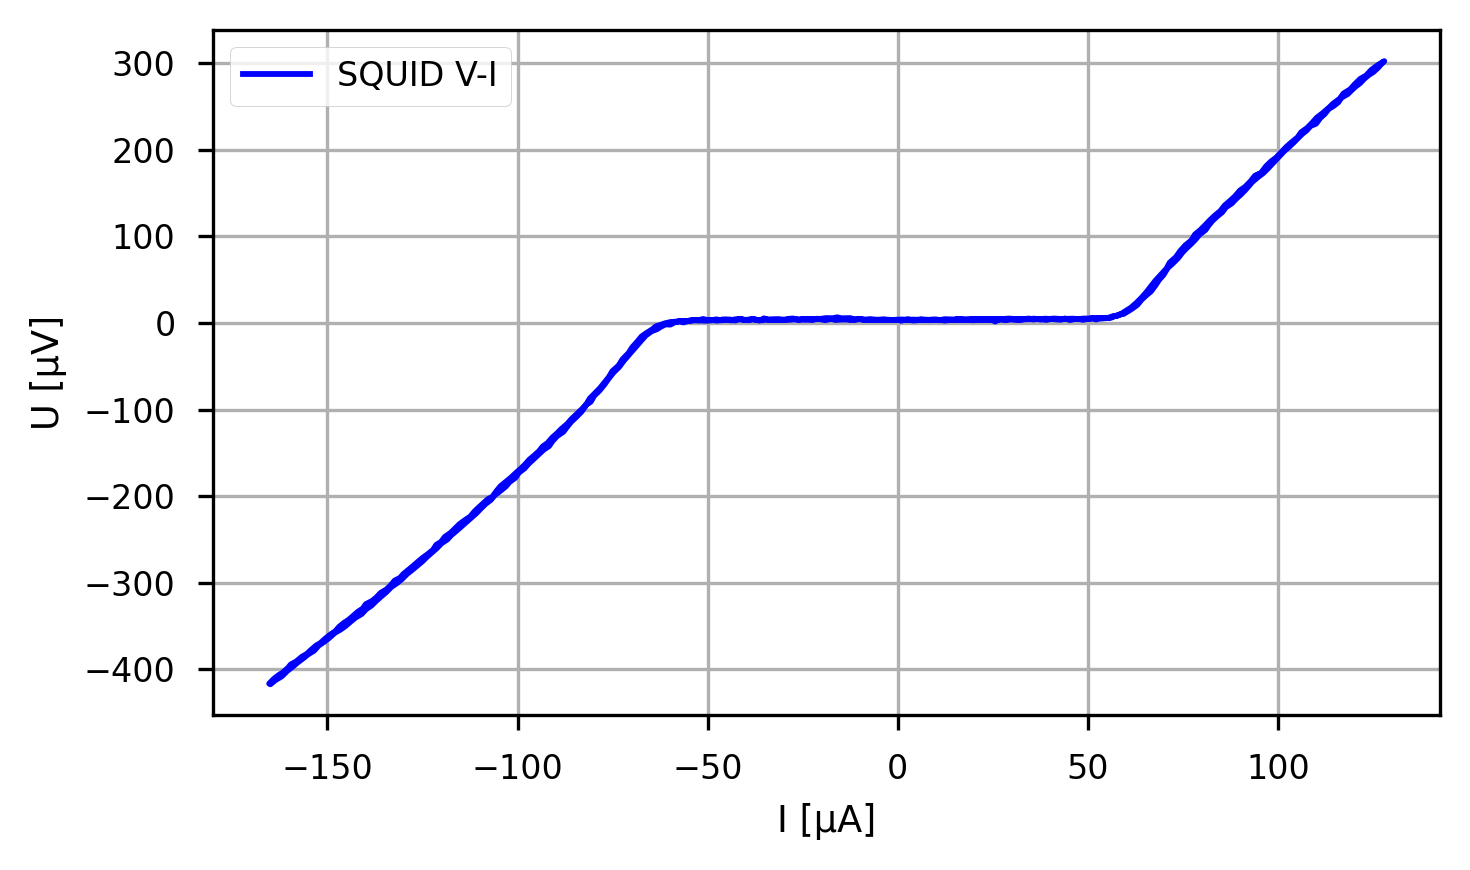

Negative branch: a = 2.8856, b = 101.5339
I_C (from negative branch x-intercept): -35.19 µA
Positive branch: a = 2.3905, b = -61.6540
I_C (from positive branch x-intercept): 25.79 µA


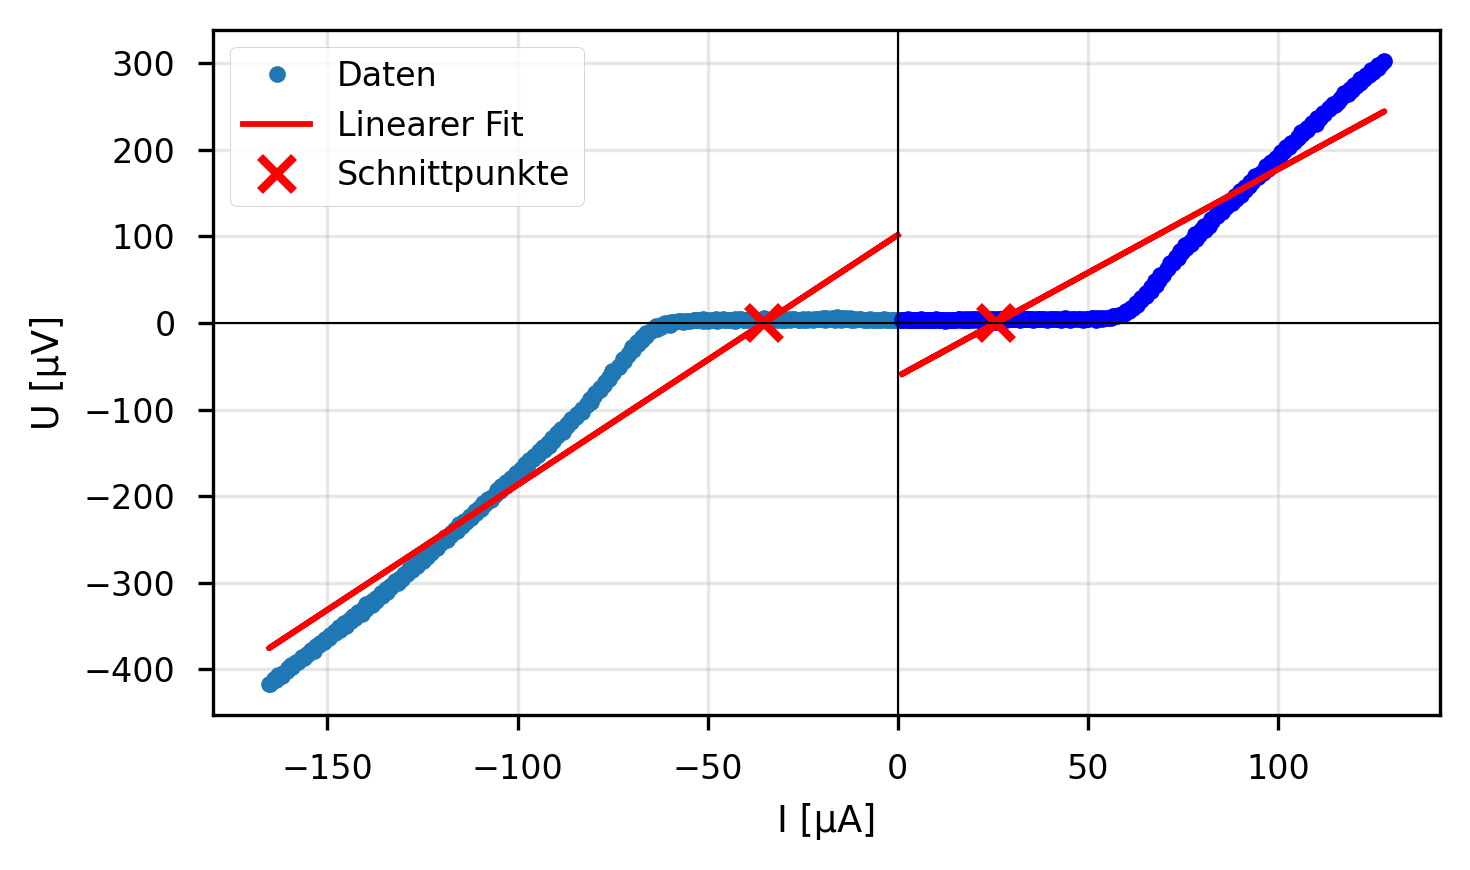


R_N (Steigung): 2.29 µV/µA = 2.29 Ω


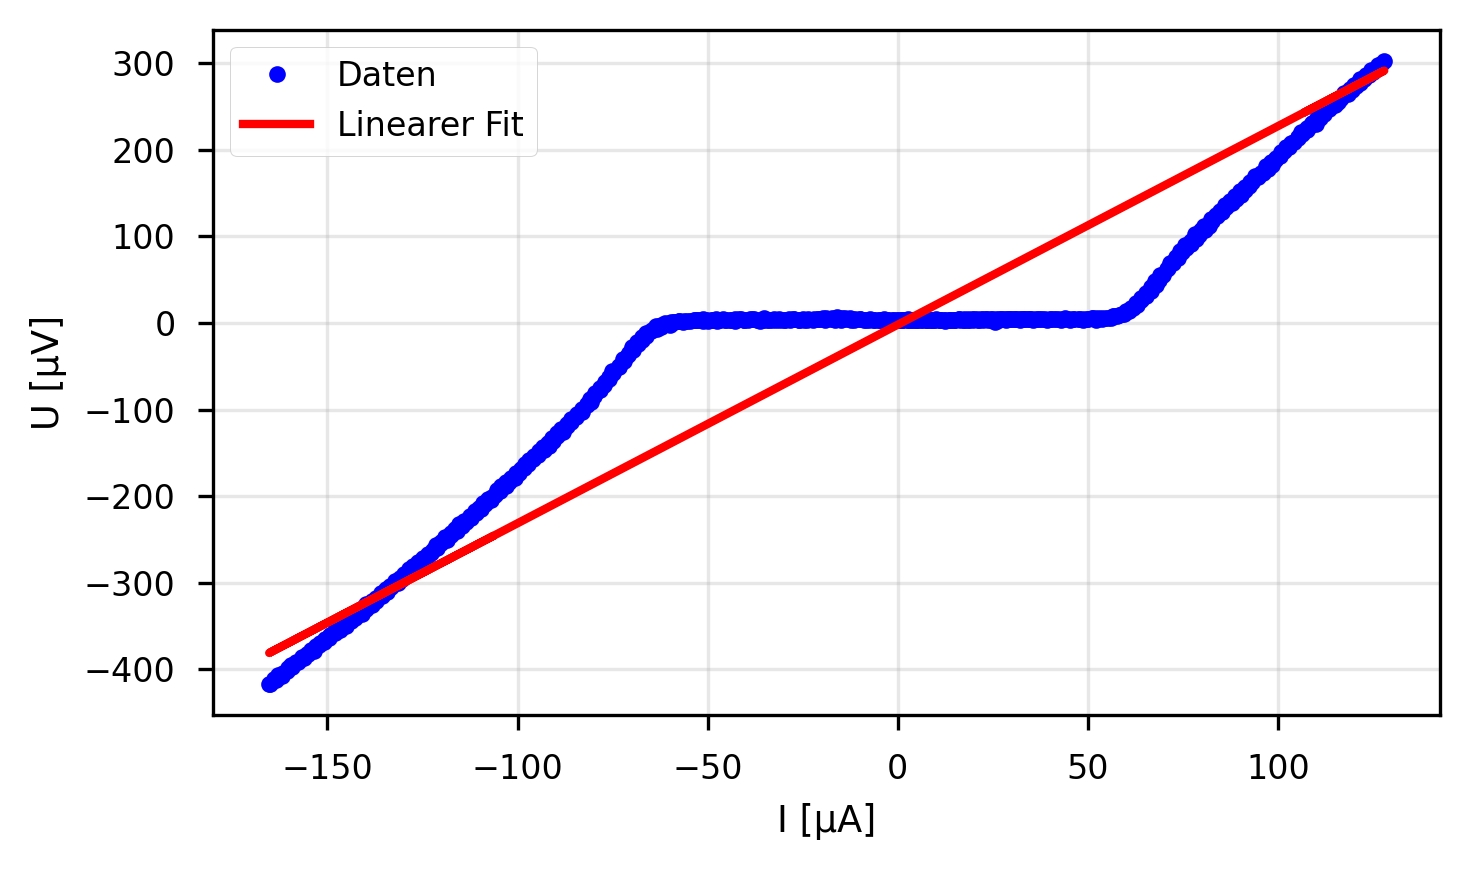


ZUSAMMENFASSUNG:
I_C (kritischer Strom): -4.70 µA
R_N (Normalwiderstand): 2.29 Ω


In [2]:
from matplotlib import rcParams
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.style as mtlstyle

from scipy.optimize import curve_fit

mtlstyle.use("seaborn-v0_8-paper")

rcParams["figure.dpi"] = 300
rcParams["figure.figsize"] = (5, 3)

# CSV einlesen
df = pd.read_csv('10_26_2011-07_21_43_internal_flux_0_nah.csv')
df.columns = df.columns.str.replace('"', '').str.strip()

# Extract data
x = df['0_x'].values
y = df['0_y'].values

# Define linear function
def linear(x, a, b):
    return a * x + b

# Plot 1: Original V-I curve
plt.figure(figsize=(5, 3))
plt.plot(x, y, label="SQUID V-I", color="blue")
plt.xlabel("I [µA]")
plt.ylabel("U [µV]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Split data into negative and positive branches
negative_branch = x < 0
positive_branch = x > 0

# Fit negative branch
if np.sum(negative_branch) > 2:
    x_neg = x[negative_branch]
    y_neg = y[negative_branch]
    popt_neg, _ = curve_fit(linear, x_neg, y_neg)
    y_fit_neg = linear(x_neg, *popt_neg)
    
    # Find x-intercept for negative branch
    I_c_neg = -popt_neg[1] / popt_neg[0]  # y = 0 => x = -b/a
    print(f"Negative branch: a = {popt_neg[0]:.4f}, b = {popt_neg[1]:.4f}")
    print(f"I_C (from negative branch x-intercept): {I_c_neg:.2f} µA")

# Fit positive branch
if np.sum(positive_branch) > 2:
    x_pos = x[positive_branch]
    y_pos = y[positive_branch]
    popt_pos, _ = curve_fit(linear, x_pos, y_pos)
    y_fit_pos = linear(x_pos, *popt_pos)
    
    # Find x-intercept for positive branch
    I_c_pos = -popt_pos[1] / popt_pos[0]
    print(f"Positive branch: a = {popt_pos[0]:.4f}, b = {popt_pos[1]:.4f}")
    print(f"I_C (from positive branch x-intercept): {I_c_pos:.2f} µA")

# Plot 2: x-intercepts and linear fits (combined in one plot)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x_neg, y_neg, 'o', label="Daten", markersize=4)
ax.plot(x_neg, y_fit_neg, '-', label="Linearer Fit", color="red")
ax.plot(x_pos, y_pos, 'o', markersize=4, color="blue")
ax.plot(x_pos, y_fit_pos, '-', color="red")
# Mark x-intercepts
ax.plot([I_c_neg, I_c_pos], [0, 0], 'x', color="red", markersize=8, markeredgewidth=2, label="Schnittpunkte")
ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax.axvline(0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel("I [µA]")
ax.set_ylabel("U [µV]")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Plot 3: R_N determination (combined fit on outer parts)
fig, ax = plt.subplots(figsize=(5, 3))
# Use outer parts for R_N fit (regions with highest |V|)
outer_threshold = np.percentile(np.abs(x), 75)
outer_mask = np.abs(x) > outer_threshold
x_outer = x[outer_mask]
y_outer = y[outer_mask]

if len(x_outer) > 2:
    popt_outer, _ = curve_fit(linear, x_outer, y_outer)
    y_fit_outer = linear(x_outer, *popt_outer)
    R_N = popt_outer[0]  # Slope is R_N in µV/µA = Ω
    print(f"\nR_N (Steigung): {R_N:.2f} µV/µA = {R_N:.2f} Ω")
    
    ax.plot(x, y, 'o', label="Daten", markersize=4, color="blue")
    ax.plot(x_outer, y_fit_outer, '-', label="Linearer Fit", color="red", linewidth=2)
    ax.set_xlabel("I [µA]")
    ax.set_ylabel("U [µV]")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

# Summary
print("\n" + "="*50)
print("ZUSAMMENFASSUNG:")
print(f"I_C (kritischer Strom): {(I_c_neg + I_c_pos)/2:.2f} µA")
print(f"R_N (Normalwiderstand): {R_N:.2f} Ω")
print("="*50)

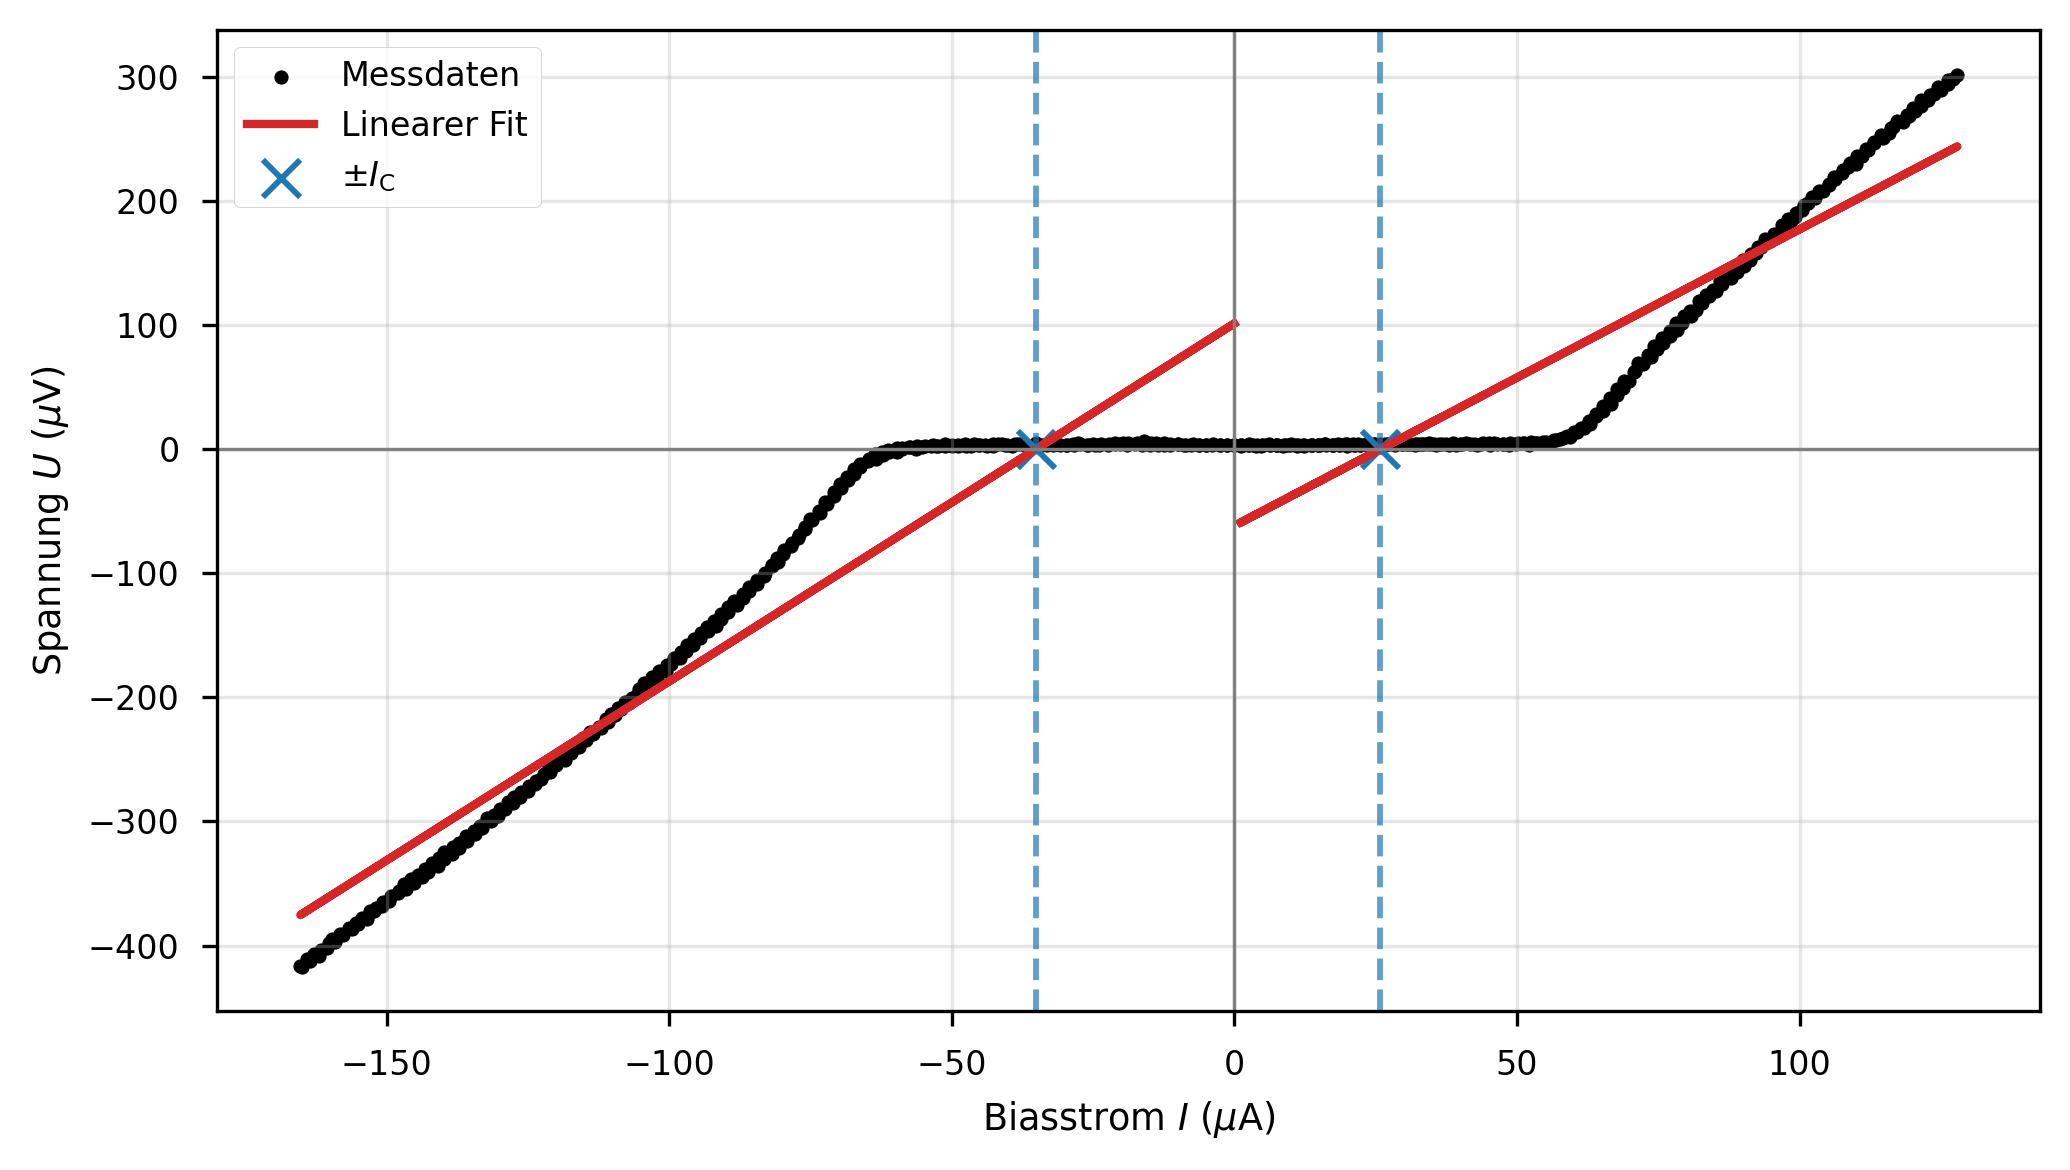

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

# Messdaten
ax.scatter(x, y, s=10, color="black", label="Messdaten")

# Fits
ax.plot(x_neg, y_fit_neg, color="tab:red", lw=2,
        label="Linearer Fit")
ax.plot(x_pos, y_fit_pos, color="tab:red", lw=2)

# Kritische Ströme markieren
ax.axvline(I_c_neg, color="tab:blue", ls="--", alpha=0.7)
ax.axvline(I_c_pos, color="tab:blue", ls="--", alpha=0.7)
ax.scatter([I_c_neg, I_c_pos], [0, 0],
           marker="x", s=80, color="tab:blue",
           label=r"$\pm I_\mathrm{C}$")

# Achsen
ax.axhline(0, color="gray", lw=0.8)
ax.axvline(0, color="gray", lw=0.8)

ax.set_xlabel(r"Biasstrom $I$ ($\mu$A)")
ax.set_ylabel(r"Spannung $U$ ($\mu$V)")
ax.legend()
ax.grid()
plt.tight_layout()